In [573]:
%load_ext autoreload
%autoreload 2
%reset -f
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [574]:
import matplotlib.pyplot as plt
from shapely import wkt
from shapely.ops import unary_union
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon
from shapely.geometry import LineString, Point
from shapely.affinity import rotate
import numpy as np
import pandas as pd
import geopandas as gpd
from inc import explode_linestrings_at_vertices


# Configuration

In [575]:
tol_deg  = 2.5
street_length = 20
sampling_distance = 5
angle = 135
dx = 1            # Thickness of each vertical bar


# Generate the arbitrary pass

## Arbitrary survey

In [576]:


# Create a DataFrame with the pass name and geometries
survey_gdf = gpd.GeoDataFrame({
    'Order': [1,2,3,4,5],
    'geometry': [
        LineString([(-800, -800),(0, 0),(-800, 800)]),
        LineString([(800, 800),(0, 700),(-800, 800)]),
        LineString([(800, 800),(0,0 ),(800, -800)]),
        LineString([(775, 775),(0, 675)]),
        LineString([(810, 810),(0, 735)])
    ]
}, geometry='geometry', crs='EPSG:3857')

In [577]:
# 2-vertex segments along each original LineString / MultiLineString
survey_gdf = explode_linestrings_at_vertices(survey_gdf)
survey_gdf['length'] = survey_gdf.geometry.length


In [578]:
# Compute the union of the survey geometries
survey_union = survey_gdf.unary_union

# Create a GeoDataFrame from the union
survey_union_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union]},
    crs=survey_gdf.crs
)

# Make an offset of 10 (buffer by 10 units)
survey_union_offset_gdf = gpd.GeoDataFrame(
    {'geometry': [survey_union.buffer(street_length/2, cap_style=2)]},
    crs=survey_gdf.crs,
    geometry='geometry'
)

# Generate the grid

## Generate the vertical lines

In [579]:
# Parameters for evenly spaced thin vertical rectangles (grid "bars")
min_x = -2000
max_x = 1000
min_y = -1000
max_y = 1000

# Compute bar center x-positions
x_centers = np.linspace(min_x, max_x, num=(max_x - min_x)//sampling_distance + 1)
# For each center, form a thin rectangle
vertical_bars = [
    Polygon([
        (x - dx/2, min_y),
        (x + dx/2, min_y),
        (x + dx/2, max_y),
        (x - dx/2, max_y)
    ])
    for x in x_centers
]

#-- Grid aligned with the base vectors [1.0], 
grid_lines_gdf = gpd.GeoDataFrame({'geometry': vertical_bars}, crs='EPSG:3857', geometry='geometry')
grid_lines_gdf['grid_idx'] = grid_lines_gdf.index

# Define the vector
vec = np.array([1,0])
ortho_vec = np.array([0,1])
# Define a rotation angle in radians (example: 45 degrees)
theta = np.deg2rad(angle)
rotation_matrix = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)]
])

# Rotate the vector by the rotation matrix
rotated_vec = rotation_matrix @ vec
ortho_vec = rotation_matrix @ ortho_vec

# Rotate the grid lines accordingly
vertical_bars_r = [rotate(bar, angle=angle, origin=(0,0)) for bar in vertical_bars]
grid_lines_gdf_r = gpd.GeoDataFrame({'geometry': vertical_bars_r}, crs='EPSG:3857', geometry='geometry')
grid_lines_gdf_r['grid_idx'] = grid_lines_gdf_r.index

In [580]:
intersection_gdf = gpd.overlay(
    grid_lines_gdf_r, 
    survey_union_offset_gdf, 
    how='intersection', 
    keep_geom_type=False
)
intersection_gdf = intersection_gdf.explode(index_parts=True)
intersection_gdf.set_geometry('geometry', inplace=True)
intersection_gdf.set_crs('EPSG:3857', inplace=True)


grid_idx                                           geometry
0   0       174  POLYGON ((805.748 -791.606, 806.455 -792.313, ...
1   0       175  POLYGON ((802.213 -788.071, 802.920 -788.778, ...
2   0       176  POLYGON ((798.677 -784.535, 799.384 -785.242, ...
3   0       177  POLYGON ((795.142 -780.999, 795.849 -781.707, ...
4   0       178  POLYGON ((791.606 -777.464, 792.313 -778.171, ...
...         ...                                                ...
424 1       598  POLYGON ((-693.318 707.460, -692.611 706.753, ...
425 0       599  POLYGON ((-620.242 787.608, -618.985 787.451, ...
    1       599  POLYGON ((-696.854 710.996, -696.147 710.289, ...
426 0       600  POLYGON ((-626.527 788.394, -625.270 788.237, ...
    1       600  POLYGON ((-700.389 714.531, -699.682 713.824, ...

[757 rows x 2 columns]

In [581]:

def get_bottom_points(geom):
    return list(dict.fromkeys(geom.boundary.coords))[-2:]


In [582]:
intersection_gdf['bottom_points'] = intersection_gdf['geometry'].apply(get_bottom_points)

In [583]:
def safe_unit_vector(bottom_points, tol=1e-8):
    """
    Returns a unit vector for the line defined by bottom_points. 
    If invalid input or the two points are extremely close, returns None.
    They are not really coincident points—just extremely close numerically.
    """
    # Validate: must be a list of 2 coordinate tuples
    if (
        isinstance(bottom_points, list)
        and len(bottom_points) == 2
        and all(isinstance(pt, tuple) and len(pt) == 2 for pt in bottom_points)
    ):
        p1 = np.array(bottom_points[0], dtype=float)
        p2 = np.array(bottom_points[1], dtype=float)
        vec = p2 - p1
        norm = np.linalg.norm(vec)

        # Instead of coincident check, check that points are not "almost" coincident
        if norm <= tol or np.any(np.isnan(vec)):
            return None

        return (vec / norm).tolist()
    # If we get here, input was not valid, so return to previous logic: None
    # (i.e., do what the old safe_unit_vector used to do on fallback)
    return None
    # Not enough points or bad input: return None
    return None

intersection_gdf['unit_vector'] = intersection_gdf['bottom_points'].apply(safe_unit_vector)

In [584]:
# Compute angle in degrees between two vectors (default: unit_vector and [1,0]), range [-180, 180]
def angle_between_vectors(vec_a, rotated_vec=[1.0, 0.0]):
    # vec_a and rotated_vec expected to be [x, y]
    a = np.array(vec_a)
    b = np.array(rotated_vec)
    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return 0.0
    # Calculate angle in radians
    dot = np.dot(a, b)
    det = a[0] * b[1] - a[1] * b[0]
    angle_rad = np.arctan2(det, dot)
    angle_deg = np.rad2deg(angle_rad)
    return angle_deg

# Use a lambda to pass the additional argument
intersection_gdf['angle'] = intersection_gdf['unit_vector'].apply(lambda vec: angle_between_vectors(vec, rotated_vec=rotated_vec))


In [585]:
intersection_gdf

grid_idx                                           geometry  \
0   0       174  POLYGON ((805.748 -791.606, 806.455 -792.313, ...   
1   0       175  POLYGON ((802.213 -788.071, 802.920 -788.778, ...   
2   0       176  POLYGON ((798.677 -784.535, 799.384 -785.242, ...   
3   0       177  POLYGON ((795.142 -780.999, 795.849 -781.707, ...   
4   0       178  POLYGON ((791.606 -777.464, 792.313 -778.171, ...   
...         ...                                                ...   
424 1       598  POLYGON ((-693.318 707.460, -692.611 706.753, ...   
425 0       599  POLYGON ((-620.242 787.608, -618.985 787.451, ...   
    1       599  POLYGON ((-696.854 710.996, -696.147 710.289, ...   
426 0       600  POLYGON ((-626.527 788.394, -625.270 788.237, ...   
    1       600  POLYGON ((-700.389 714.531, -699.682 713.824, ...   

                                           bottom_points  \
0   0  [(792.3131483195267, -806.4552839432574), (791...   
1   0  [(788.7776144135938, -802.9197500373245), (788...   
2   0  [(785.2420805076612, -799.3842161313919), (784...   
3   0  [(781.7065466017284, -795.8486822254592), (780...   
4   0  [(778.1710126957956, -792.3131483195265), (777...   
...                                                  ...   
424 1  [(-706.7532277959541, 692.6110921722232), (-70...   
425 0  [(-636.90063108037, 769.534756699673), (-638.1...   
    1  [(-710.2887617018869, 696.146626078156), (-710...   
426 0  [(-643.1860246909171, 770.3204309009914), (-64...   
    1  [(-713.8242956078196, 699.6821599840887), (-71...   

                                      unit_vector         angle  
0   0   [-0.7071067811865476, 0.7071067811865476] -6.361109e-15  
1   0   [-0.7071067811866044, 0.7071067811864907] -4.611804e-12  
2   0   [-0.7071067811866043, 0.7071067811864906] -4.611804e-12  
3   0   [-0.7071067811864907, 0.7071067811866044]  4.602263e-12  
4   0   [-0.7071067811864907, 0.7071067811866044]  4.602263e-12  
...                                           ...           ...  
424 1   [-0.7071067811864907, 0.7071067811866044]  4.602263e-12  
425 0  [-0.9922778767136677, 0.12403473458920847] -3.787498e+01  
    1   [-0.7071067811865476, 0.7071067811865476] -6.361109e-15  
426 0  [-0.9922778767136594, 0.12403473458927472] -3.787498e+01  
    1   [-0.7071067811864907, 0.7071067811866044]  4.602263e-12  

[757 rows x 5 columns]

In [586]:
intersection_gdf['angle'].describe()

count    7.570000e+02
mean    -1.899480e+01
std      2.821602e+01
min     -9.000000e+01
25%     -5.029008e+01
50%     -2.309083e-12
75%     -6.361109e-15
max      1.800000e+02
Name: angle, dtype: float64

<Axes: >

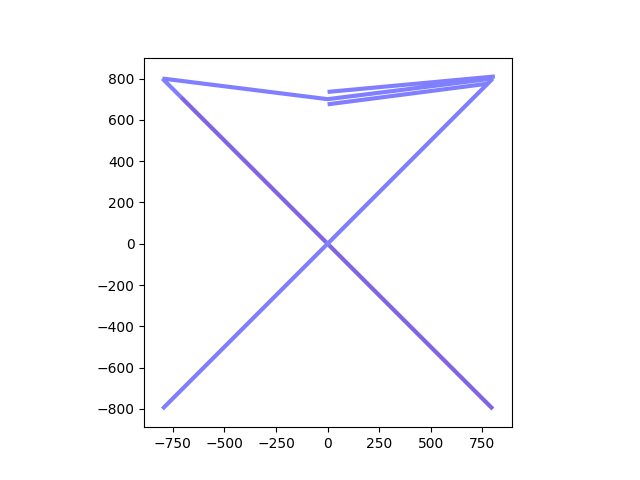

In [587]:
fig, ax = plt.subplots()
right_angles = intersection_gdf[np.isclose(intersection_gdf['angle'], 0, atol=tol_deg)]
joined = gpd.sjoin(survey_gdf, right_angles, how='right', predicate='intersects')
joined['Order'].value_counts()
right_angles.plot(ax=ax, color='red')
survey_union_offset_gdf.plot(ax=ax, color='blue', alpha=0.5)

In [588]:
right_angles

,,grid_idx,geometry,bottom_points,unit_vector,angle
0,0,174,"POLYGON ((805.748 -791.606, 806.455 -792.313, ...","[(792.3131483195267, -806.4552839432574), (791...","[-0.7071067811865476, 0.7071067811865476]",-6.361109e-15
1,0,175,"POLYGON ((802.213 -788.071, 802.920 -788.778, ...","[(788.7776144135938, -802.9197500373245), (788...","[-0.7071067811866044, 0.7071067811864907]",-4.611804e-12
2,0,176,"POLYGON ((798.677 -784.535, 799.384 -785.242, ...","[(785.2420805076612, -799.3842161313919), (784...","[-0.7071067811866043, 0.7071067811864906]",-4.611804e-12
3,0,177,"POLYGON ((795.142 -780.999, 795.849 -781.707, ...","[(781.7065466017284, -795.8486822254592), (780...","[-0.7071067811864907, 0.7071067811866044]",4.602263e-12
4,0,178,"POLYGON ((791.606 -777.464, 792.313 -778.171, ...","[(778.1710126957956, -792.3131483195265), (777...","[-0.7071067811864907, 0.7071067811866044]",4.602263e-12
...,...,...,...,...,...,...
422,1,596,"POLYGON ((-686.247 700.389, -685.540 699.682, ...","[(-699.6821599840887, 685.5400243603577), (-70...","[-0.7071067811865476, 0.7071067811865476]",-6.361109e-15
423,1,597,"POLYGON ((-689.783 703.925, -689.076 703.218, ...","[(-703.2176938900213, 689.0755582662905), (-70...","[-0.7071067811866044, 0.7071067811864907]",-4.611804e-12
424,1,598,"POLYGON ((-693.318 707.460, -692.611 706.753, ...","[(-706.7532277959541, 692.6110921722232), (-70...","[-0.7071067811864907, 0.7071067811866044]",4.602263e-12
425,1,599,"POLYGON ((-696.854 710.996, -696.147 710.289, ...","[(-710.2887617018869, 696.146626078156), (-710...","[-0.7071067811865476, 0.7071067811865476]",-6.361109e-15


In [589]:
def get_line_from_angle(row):
    tol = 10
    top = tuple(np.array(row.geometry.centroid.coords[0]) + (row.geometry.length/2 + tol) * np.array(ortho_vec))
    bottom = tuple(np.array(row.geometry.centroid.coords[0]) - (row.geometry.length/2 + tol) * np.array(ortho_vec))
    return LineString([top, bottom])

# Create a new GeoDataFrame for plotting if needed
right_angles = right_angles.copy()
right_angles['cell_boundary'] = right_angles.apply(get_line_from_angle, axis=1)

#filter
#right_angles = right_angles[right_angles['cell_boundary'].length < 100]
mask = right_angles['unit_vector'].apply(lambda x: x == [0.0, 0.0])
filtered_right_angles = right_angles
#filtered_right_angles = right_angles[~mask]
#filtered_right_angles.set_geometry('cell_boundary').plot(ax=ax, color='red')

/home/sandbox/personal-repos/.venv/lib/python3.9/site-packages/pandas/core/dtypes/cast.py:130: ShapelyDeprecationWarning: The array interface is deprecated and will no longer work in Shapely 2.0. Convert the '.coords' to a numpy array instead.
  arr = construct_1d_object_array_from_listlike(values)


<Axes: >

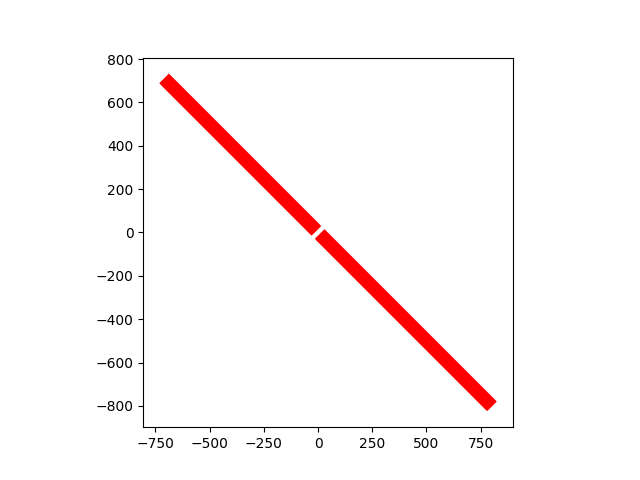

In [590]:
fig, ax = plt.subplots()
filtered_right_angles.set_geometry('cell_boundary').plot(ax=ax, color='red')

422 splitters -> 422 cells


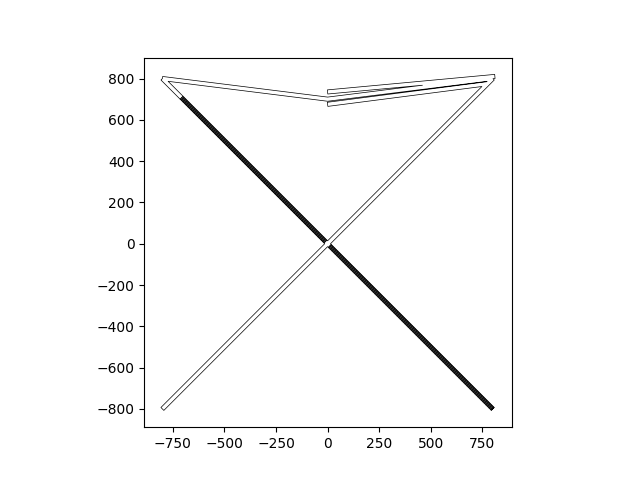

In [591]:
from shapely.ops import polygonize, unary_union
# Build cells from the full line arrangement (do NOT call split(geom, line) in a loop on the same
# `geom` — each call only uses one line against the original polygon, so cuts never combine).

geom = survey_union_offset_gdf.iloc[0].geometry
fra = filtered_right_angles.sort_values("grid_idx", inplace=False)

# All grid lines as one noded multiline (tweak attribute if your geometry column differs)
lines = [getattr(row, "cell_boundary") for row in fra.itertuples()]
splitters = unary_union(lines)

# Closed faces = polygon boundary ∪ splitters, then polygonize the resulting line network
network = unary_union([geom.boundary, splitters])
cell_polys = [
    poly
    for poly in polygonize(network)
    if geom.contains(poly.representative_point())
]

print(len(lines), "splitters ->", len(cell_polys), "cells")

fig, ax = plt.subplots()
gpd.GeoSeries(cell_polys, crs=survey_union_offset_gdf.crs).plot(
    ax=ax, edgecolor="black", facecolor="none", linewidth=0.5
)
plt.show()